In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

CNN

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Loading the mnist dataset for handwritten numbers

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


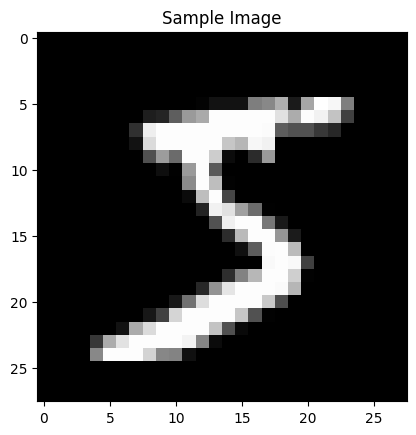

Label: 5


In [ ]:
plt.imshow(X_train[0], cmap='gray')
plt.title("Sample Image")
plt.show()

print("Label:", y_train[0])

In [ ]:
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

print("New Training Shape:", X_train.shape)
# (samples, height, width, channels)

New Training Shape: (60000, 28, 28, 1)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalized Data Sample:")
print(X_train[0])

Normalized Data Sample:
[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.       

Why normalization is needed

✅ Reason 1: Faster learning
Neural networks work best when inputs are small:
Large values → slow training
Small values → faster convergence

✅ Reason 2: Stable gradients
Without normalization:
Weights update → unstable
With normalization:
Smooth learning

In [ ]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 1. Convolution Layer 1
        32 number of filters [a small 3x3 matrix] that slide over the image. Each filter produces a feature map, so 32 filters have 32 feature maps [32 different patterns in image]. 28x28x1 is the shape of the image and the channel. We use ReLU here to add non linearity understanding.

### 2. MaxPooling Layer
        Reduce size. In a 2x2 region only take the max value to remove noise.

### 3. Convolution Layer 2
        Here we are applying 64 filters to find complex patterns.

### 4. Second Pooling
        Further reduces size to keep strong features

### 5. Flatten Layer
        Changes the 2D feature map into 1D vector as dense layer need 1D input. Eg (5×5×64) → (1600)

### 6. Dense Layer
        The fully connected layer that learns the final patterns.

### 7. Dropout
        Randomly turns of 0.5 or 50% of total neurons to prevent overfitting

### 8. Output Layer
        We have 10 neurons in this layer since we have 10 classes (0-9). We have used softmax as output is probability for each class with sum = 1. How much probability of given input to belong in each of the class.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Categorical as we are directly giving label class and sparse because it is compact form of label
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9135 - loss: 0.2830 - val_accuracy: 0.9781 - val_loss: 0.0728
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9724 - loss: 0.0951 - val_accuracy: 0.9848 - val_loss: 0.0530
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9786 - loss: 0.0716 - val_accuracy: 0.9871 - val_loss: 0.0431
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.9840 - loss: 0.0548 - val_accuracy: 0.9893 - val_loss: 0.0392
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9858 - loss: 0.0472 - val_accuracy: 0.9897 - val_loss: 0.0385


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9907 - loss: 0.0275
Test Accuracy: 0.9907000064849854
Test Loss: 0.027513306587934494


In [ ]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
[7 2 1 0 4 1 4 9 5 9]


Since the output is a row with probability of occurance 1 sample in each class we are using the argmax to find the index of maximum value (which here corresponds to the label class)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_labels)

print(cm)

[[ 976    1    0    0    0    0    1    1    1    0]
 [   0 1132    1    1    0    0    1    0    0    0]
 [   1    0 1024    0    0    0    0    6    1    0]
 [   0    0    3  999    0    4    0    2    2    0]
 [   0    0    0    0  979    0    1    0    0    2]
 [   2    0    1    7    0  878    1    1    1    1]
 [   2    2    0    0    1    3  948    0    2    0]
 [   0    2    2    1    0    0    0 1021    0    2]
 [   3    0    2    1    1    0    1    1  963    2]
 [   3    1    0    3    6    5    0    2    2  987]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



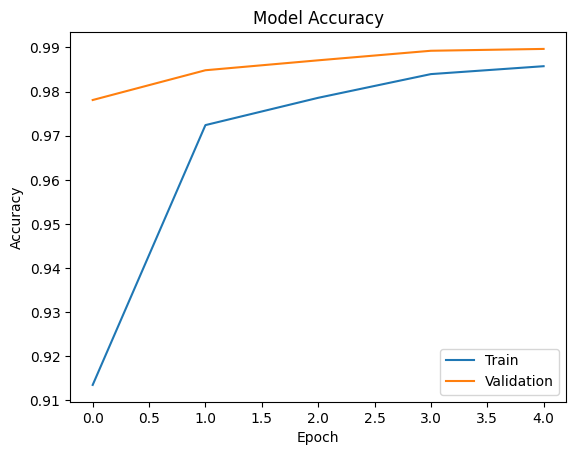

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

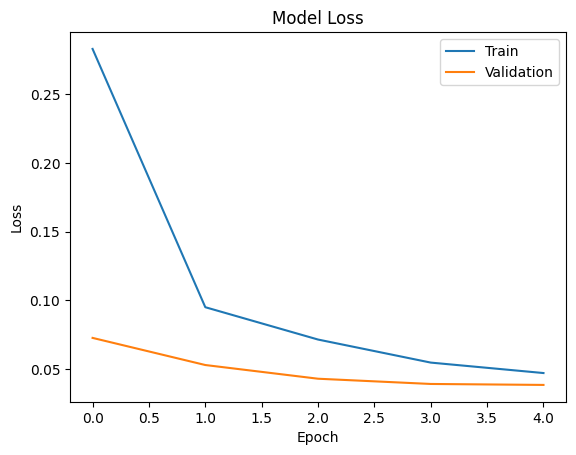

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()